# Dam break (Marrone et al. 2011, §3.1)

The classical free-surface benchmark: a water column $2H\times H$ ($H=0.6$) in the left corner of a closed tank $5.366\,H$ long collapses under gravity, runs along the bed as a thin front, hits the right
wall and rolls back. There is no closed-form solution after the first instants, so the references are

* **Ritter's dry-bed solution** for the early front: after the collapse the front moves at $2\sqrt{g h_0}$, an upper bound that the real front approaches from below (bed friction, finite aspect ratio);
* the **warpSPH** run of the same case (`results/deltasph/dambreak_warpSPH_nx67_series.npz`: Sun-type δ⁺-SPH with mDBC boundary particles, nx = 67): kinetic energy and fastest particle against time;
* the other scheme of this package (run the notebook with the other `SCHEME` and the stored series is overlaid).

The walls are exact analytic walls (no boundary particles).

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"

In [2]:
import math, os
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries import paths
from warpSPHBoundaries.sim.dfsph2d import domain_scene
from warpSPHBoundaries.sim.references import ritter_front
from warpSPHBoundaries.sim.solvers import make_solver, box_lattice, lattice_constants, save_series, load_series

g, H, Lref = 9.81, 0.6, 1.0
nx = {"quick": 40, "full": 67}[QUALITY]              # nx = Lref / dx (the stored warpSPH run is nx = 67)
T = {"quick": 0.9, "full": 1.9}[QUALITY]
dx = Lref / nx
Wt = 5.366 * H

## Set-up
Tank interior $(W_t-dx)\times(L-dx)$, the column in the left corner. `box_lattice` places the first row at the scheme's wall gap.

In [3]:
cells = (int(round(Wt / dx)) - 1, nx - 1)
pos, hi = box_lattice(SCHEME, (0.0, 0.0), cells, dx, walls=(True, True))
gap = pos[:, 0].min()
i = np.round((pos[:, 0] - gap) / dx).astype(int); j = np.round((pos[:, 1] - gap) / dx).astype(int)
col = (i < int(math.ceil(2 * H / dx - 1e-9))) & (j < int(math.floor(H / dx + 1e-9)))
pos = pos[col]
scene = domain_scene("surface", (0.0, 0.0), hi, lattice_constants(SCHEME, dx)["h"], DEVICE)
c0 = 40.0 * math.sqrt(g * H)
extra = {"maxDt": 1e-3} if SCHEME == "dfsph" else {}
sol = make_solver(SCHEME, pos, dx, scene, nu=0.0, gravity=(0.0, -g), c0=c0, device=DEVICE, **extra)
print(f"scheme {SCHEME}: N = {sol.n}, tank {hi[0]:.3f} x {hi[1]:.3f}, column {2 * H:.2f} x {H:.2f}, dx = {dx:.4f}")

t, front, ke, vmax, rmin, rmax = [], [], [], [], [], []
x0 = float(pos[:, 0].max())
def record(s):
    t.append(s.time); front.append(float(s.x[:, 0].max()) - x0)
    ke.append(0.5 * float((s.volume * (s.v ** 2).sum(1)).sum())); vmax.append(float(np.linalg.norm(s.v, axis=1).max()))
    rmin.append(float(s.rho.min())); rmax.append(float(s.rho.max()))

scheme delta: N = 1152, tank 3.200 x 0.975, column 1.20 x 0.60, dx = 0.0250


## Integration

In [4]:
sol.run(T, every=T / 6, callback=record, report=lambda s: f"front +{front[-1]:.3f}  KE {ke[-1]:.4f}  rho [{rmin[-1]:.3f}, {rmax[-1]:.3f}]")
save_series("dam_break", SCHEME, t=t, front=front, ke=ke, vmax=vmax, nx=nx)

  t    0.150  dt 1.63e-04  vmax    2.755  front +0.221  KE 0.1648  rho [1.000, 1.001]  [25 s]


  t    0.300  dt 1.63e-04  vmax    3.658  front +0.713  KE 0.4411  rho [1.000, 1.001]  [41 s]


  t    0.450  dt 1.63e-04  vmax    4.151  front +1.302  KE 0.6714  rho [1.000, 1.000]  [59 s]


  t    0.600  dt 1.63e-04  vmax    4.433  front +1.946  KE 0.8746  rho [1.000, 1.000]  [77 s]


  t    0.750  dt 1.63e-04  vmax    5.402  front +2.007  KE 0.9888  rho [0.998, 1.003]  [98 s]


  t    0.900  dt 1.63e-04  vmax    5.269  front +2.010  KE 0.9696  rho [0.999, 1.002]  [117 s]


## Comparison

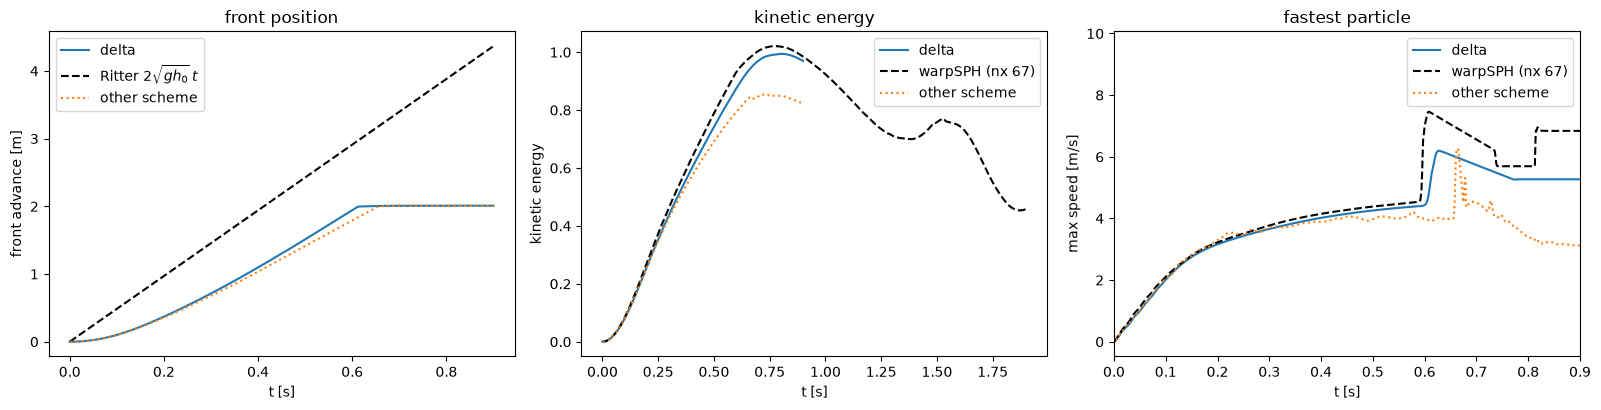

t = 0.2: KE 0.2601 (warpSPH 0.2743, ratio 0.948),  max speed 3.16 (warpSPH 3.22),  front 0.370  Ritter 0.970
t = 0.4: KE 0.5981 (warpSPH 0.6342, ratio 0.943),  max speed 4.02 (warpSPH 4.15),  front 1.098  Ritter 1.941
t = 0.6: KE 0.8746 (warpSPH 0.9304, ratio 0.940),  max speed 4.43 (warpSPH 6.97),  front 1.946  Ritter 2.911
t = 0.8: KE 0.9942 (warpSPH 1.0191, ratio 0.976),  max speed 5.27 (warpSPH 5.69),  front 2.008  Ritter 3.882
density band over the run [0.9958, 1.0053]


In [5]:
t, front, ke, vmax = map(np.array, (t, front, ke, vmax))
ref = np.load(paths.results_dir() / "deltasph" / "dambreak_warpSPH_nx67_series.npz", allow_pickle=True)
other = load_series("dam_break", "dfsph" if SCHEME == "delta" else "delta")

tstar = t * math.sqrt(g / H)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(t, front, label=SCHEME); ax[0].plot(t, ritter_front(t, H, g), "k--", label=r"Ritter $2\sqrt{gh_0}\,t$")
if other is not None: ax[0].plot(other["t"], other["front"], ":", label="other scheme")
ax[0].set(xlabel="t [s]", ylabel="front advance [m]", title="front position"); ax[0].legend()
ax[1].plot(t, ke, label=SCHEME); ax[1].plot(ref["t"], ref["kineticEnergy"], "k--", label="warpSPH (nx 67)")
if other is not None: ax[1].plot(other["t"], other["ke"], ":", label="other scheme")
ax[1].set(xlabel="t [s]", ylabel="kinetic energy", title="kinetic energy"); ax[1].legend()
ax[2].plot(t, vmax, label=SCHEME); ax[2].plot(ref["t"], ref["maxVelocity"], "k--", label="warpSPH (nx 67)")
if other is not None: ax[2].plot(other["t"], other["vmax"], ":", label="other scheme")
ax[2].set(xlabel="t [s]", ylabel="max speed [m/s]", title="fastest particle"); ax[2].legend(); ax[2].set_xlim(0, T)
plt.tight_layout(); plt.show()

for tc in (0.2, 0.4, 0.6, 0.8):
    if tc <= t[-1]:
        k, kr = np.searchsorted(t, tc), np.searchsorted(ref["t"], tc)
        print(f"t = {tc:.1f}: KE {ke[k]:.4f} (warpSPH {ref['kineticEnergy'][kr]:.4f}, ratio {ke[k] / ref['kineticEnergy'][kr]:.3f}),  max speed {vmax[k]:.2f} (warpSPH {ref['maxVelocity'][kr]:.2f}),  front {front[k]:.3f}  Ritter {ritter_front(tc, H, g):.3f}")
print(f"density band over the run [{min(rmin):.4f}, {max(rmax):.4f}]")

## What to look at

* before the impact (about $t^*=t\sqrt{g/H}\approx 2.5$, i.e. $t\approx0.6$ s) the kinetic energy of both schemes follows the warpSPH run to a few per cent; after it the flow is a splash and the schemes differ in how much they dissipate;
* the front stays below Ritter's bound;
* the density band is the compressibility error of `delta` (with the case's $c_0=40\sqrt{gH}$) and the residual of the pressure solve for `dfsph`.